In [1]:
%matplotlib ipympl

import os

# Set to a very large number (e.g., 2^40 or about 1 trillion pixels)
# The value must be passed as a string.
os.environ["OPENCV_IO_MAX_IMAGE_PIXELS"] = str(2**40)

import cv2
import numpy as np
import ezdxf
import matplotlib.pyplot as plt
import math
import metrology_lib as ml

In [2]:
# --- Configuration ---
PATH = "F:/LEM-X/Masks/Metrology/"
IMAGE_PATH = PATH + "grid.bmp"

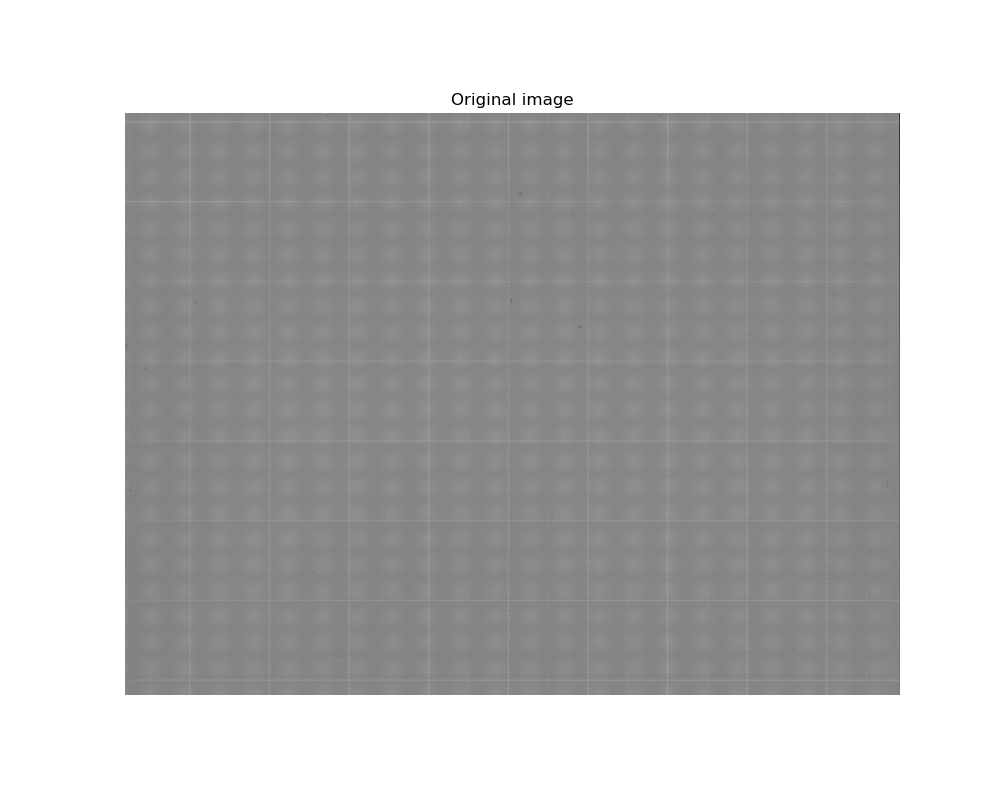

In [3]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
subimg = img[5000:40000,2000:]
del img
ml.show_image(subimg, 'Original image', 0.1)

In [4]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(3, 3))
equalized = clahe.apply(subimg)

In [5]:
otsu_fac=2
blurred = cv2.GaussianBlur(equalized, (3, 3), 0)
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + otsu_fac * cv2.THRESH_OTSU)
del equalized
del blurred

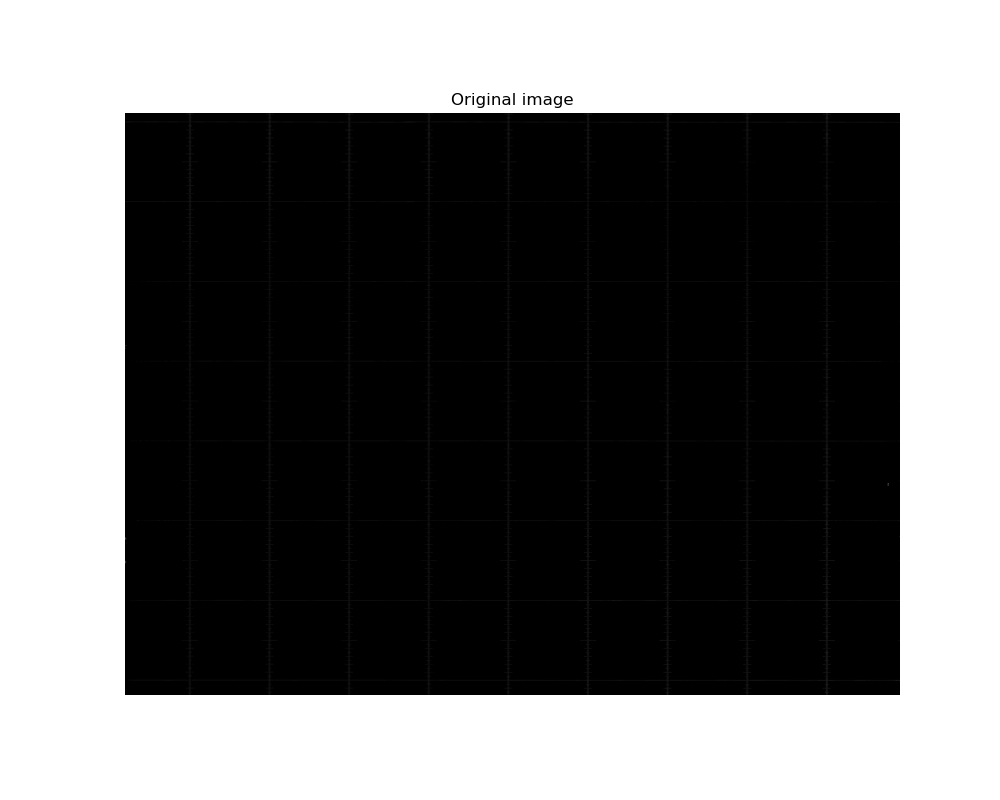

In [6]:
kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT,(1,21))
kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT,(21,1))

clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_h)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_DILATE, kernel_h)

#clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN, kernel_h)
#clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_DILATE, kernel_h)


ml.show_image(clean_mask, 'Original image', 0.1)

In [7]:
print(f"Data type: {clean_mask.dtype}")
print(f"Shape: {clean_mask.shape}")
clean_mask = np.ascontiguousarray(clean_mask)

Data type: uint8
Shape: (35000, 46588)


Extraction complete! Found 135 vertical line segments.


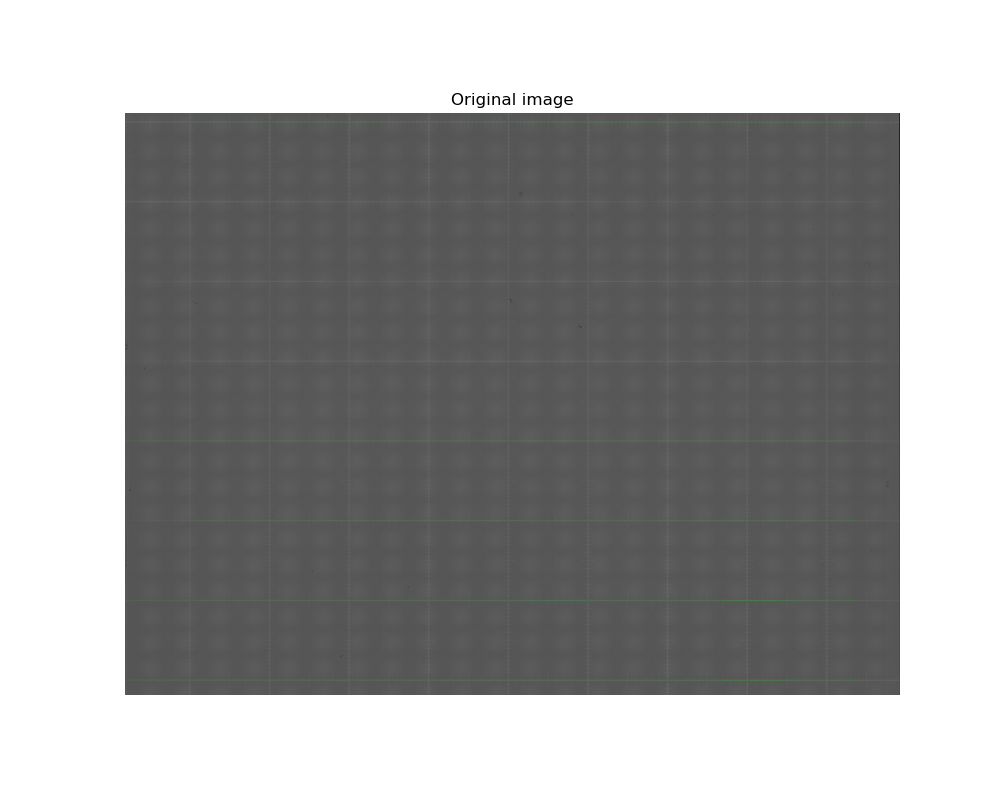

First line segment coordinates: Start(4000, 598) to End(7999, 598)


In [8]:
# Assuming clean_mask is (47750, 47388) too big for openCV to process

# Define the size of the chunks. 
# 4000x4000 is usually a safe sweet spot for memory and speed.
chunk_size = 4000
h, w = clean_mask.shape

# List to store our final, global coordinates
global_lines = []

# Iterate over the image in a grid pattern
for y in range(0, h, chunk_size):
    for x in range(0, w, chunk_size):
        
        # 1. Extract the local chunk
        # NumPy slicing automatically handles the edges if y+chunk_size exceeds the image height
        chunk = clean_mask[y : y + chunk_size, x : x + chunk_size]
        
        # Ensure contiguous memory to prevent C++ crashes
        chunk = np.ascontiguousarray(chunk)
        
        # 2. Optimization: Skip empty chunks completely
        # If there are no white pixels in this chunk, don't waste time running Hough
        if cv2.countNonZero(chunk) == 0:
            continue
            
        # 3. Run Probabilistic Hough Transform on the local chunk
        # You will need to tune these parameters based on line thickness and noise
        linesP = cv2.HoughLinesP(
            chunk, 
            rho=2, 
            theta=np.pi/180, 
            threshold=250, 
            minLineLength=3900, 
            maxLineGap=2000
        )
        
        # 4. Map local coordinates back to the global image
        if linesP is not None:
            for line in linesP:
                local_x1, local_y1, local_x2, local_y2 = line[0]
                
                # Add the chunk's offset to get the true position in the 47k x 47k image
                global_x1 = local_x1 + x
                global_y1 = local_y1 + y
                global_x2 = local_x2 + x
                global_y2 = local_y2 + y
                
                # Optional filter: Keep only roughly vertical segments
                # (where the change in X is greater than the change in Y)
                dx = abs(global_x2 - global_x1)
                dy = abs(global_y2 - global_y1)
                
                if dx > dy: 
                    global_lines.append((global_x1, global_y1, global_x2, global_y2))

print(f"Extraction complete! Found {len(global_lines)} vertical line segments.")

result_img = cv2.cvtColor(subimg, cv2.COLOR_GRAY2BGR)

for line in global_lines:
    x1, y1, x2, y2 = line
    cv2.line(result_img, (x1, y1), (x2, y2), (0, 255, 0), 3)


ml.show_image(result_img, 'Original image', 0.1)

# Example of how to access the first extracted line:
if global_lines:
    x1, y1, x2, y2 = global_lines[0]
    print(f"First line segment coordinates: Start({x1}, {y1}) to End({x2}, {y2})")

Grouped 135 segments into 8 continuous lines.


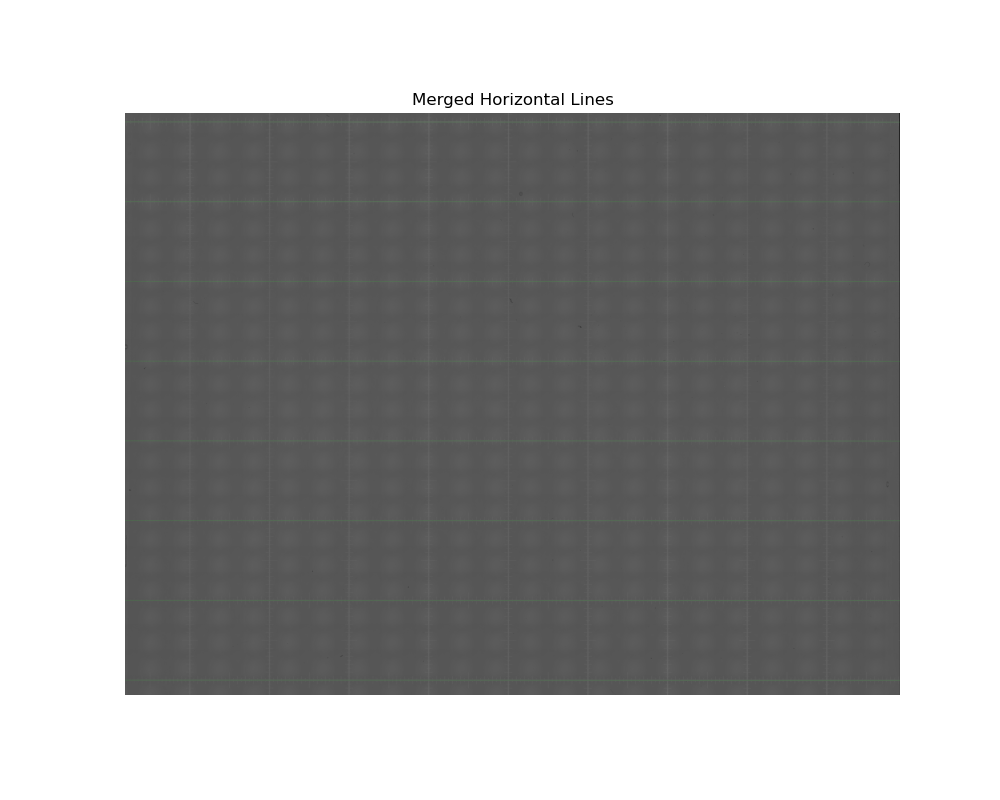

In [9]:
import numpy as np
import cv2

# --- 1. Group the segments by their Y-coordinate ---
# Calculate the midpoint Y for each segment to use as a sorting key
segments_with_y = []
for x1, y1, x2, y2 in global_lines:
    mid_y = (y1 + y2) / 2.0
    segments_with_y.append((mid_y, x1, y1, x2, y2))

# Sort all segments from top to bottom across the image
segments_with_y.sort(key=lambda item: item[0])

# Group them based on a pixel tolerance
grouped_segments = []
current_group = []
y_tolerance = 50  # Adjust this based on how thick/wobbly your lines are

for seg in segments_with_y:
    mid_y = seg[0]
    
    if not current_group:
        current_group.append(seg)
    else:
        # Check against the average Y of the current group
        group_avg_y = np.mean([item[0] for item in current_group])
        
        if abs(mid_y - group_avg_y) <= y_tolerance:
            # It belongs to the same horizontal line
            current_group.append(seg)
        else:
            # It's a new horizontal line! Save the old group and start a new one
            grouped_segments.append(current_group)
            current_group = [seg]

# Don't forget to add the last group
if current_group:
    grouped_segments.append(current_group)

print(f"Grouped {len(global_lines)} segments into {len(grouped_segments)} continuous lines.")

# --- 2. Fit a single continuous line to each group ---
merged_lines = []
w = subimg.shape[1]  # Get the full width of your image

for group in grouped_segments:
    # Collect all the starting and ending points from the segments in this group
    points = []
    for _, x1, y1, x2, y2 in group:
        points.append([x1, y1])
        points.append([x2, y2])
        
    points = np.array(points)
    
    # cv2.fitLine uses least squares to find the best mathematical line through the points
    [vx, vy, x0, y0] = cv2.fitLine(points, cv2.DIST_L2, 0, 0.01, 0.01)
    
    # Extract the scalar values
    vx, vy, x0, y0 = vx[0], vy[0], x0[0], y0[0]
    
    # Avoid division by zero in the rare case of a perfectly vertical segment sneaking in
    if vx == 0:
        vx = 1e-6 
        
    # Calculate where this line hits the left (X=0) and right (X=w) of the image
    # Using the modified line equation: y = (x - x0) * (vy / vx) + y0
    x_start = 0
    y_start = int(((x_start - x0) * (vy / vx)) + y0)
    
    x_end = w
    y_end = int(((x_end - x0) * (vy / vx)) + y0)
    
    merged_lines.append((x_start, y_start, x_end, y_end))

# --- 3. Plot the final merged lines ---
result_img_merged = cv2.cvtColor(subimg, cv2.COLOR_GRAY2BGR)

for line in merged_lines:
    x1, y1, x2, y2 = line
    cv2.line(result_img_merged, (x1, y1), (x2, y2), (0, 255, 0), 3)

ml.show_image(result_img_merged, 'Merged Horizontal Lines', 0.1)

In [10]:
# --- 1. Extract Midpoints and Sort ---
# Calculate the midpoint Y-coordinate for each line to measure the distance
# Since your lines run from x=0 to x=w, the midpoint Y is exactly halfway
midpoints_y = [(y1 + y2) / 2.0 for x1, y1, x2, y2 in merged_lines]

# Ensure the lines are strictly sorted from top to bottom
sorted_indices = np.argsort(midpoints_y)
sorted_lines = [merged_lines[i] for i in sorted_indices]
sorted_midpoints = [midpoints_y[i] for i in sorted_indices]

# --- 2. Calculate Vertical Distances ---
# np.diff calculates the difference between consecutive elements in the array
apparent_pixel_distances = np.diff(sorted_midpoints)

# --- 3. Correct for Tilt (Perpendicular Distance) ---
# Calculate the angle of each line relative to the horizontal X-axis
angles_rad = []
for x1, y1, x2, y2 in sorted_lines:
    dx = x2 - x1
    dy = y2 - y1
    # Avoid division by zero in the rare case of a perfectly vertical segment
    if dx != 0:
        angles_rad.append(math.atan(abs(dy) / abs(dx)))
    else:
        angles_rad.append(0)

mean_angle_rad = np.mean(angles_rad)
mean_angle_deg = math.degrees(mean_angle_rad)

# Apply the trigonometric correction to get the shortest path between lines
# Formula: true_distance = apparent_distance * cos(theta)
true_pixel_distances = apparent_pixel_distances * math.cos(mean_angle_rad)

# --- 4. Statistical Breakdown ---
mean_dist = np.mean(true_pixel_distances)
std_dist = np.std(true_pixel_distances)
min_dist = np.min(true_pixel_distances)
max_dist = np.max(true_pixel_distances)

print(f"Analyzed {len(true_pixel_distances)} gaps between horizontal lines.")
print(f"Average Grid Tilt: {mean_angle_deg:.4f} degrees\n")

print(f"--- PIXEL DISTANCE METRICS ---")
print(f"Mean Distance: {mean_dist:.2f} pixels")
print(f"Std Deviation: {std_dist:.2f} pixels")
print(f"Min Distance : {min_dist:.2f} pixels")
print(f"Max Distance : {max_dist:.2f} pixels\n")

# --- 5. Final Microscope Calibration ---
# *** CHANGE THIS VARIABLE TO YOUR ACTUAL PHYSICAL GRID SPACING ***
# For example, if the lines are physically 10000 micrometers apart:
known_physical_distance_um = 10000.0 

resolution = known_physical_distance_um / mean_dist

print(f"--- FINAL CALIBRATION ---")
print(f"Resolution: {resolution:.6f} µm/pixel")

Analyzed 7 gaps between horizontal lines.
Average Grid Tilt: 0.0126 degrees

--- PIXEL DISTANCE METRICS ---
Mean Distance: 4786.79 pixels
Std Deviation: 1.10 pixels
Min Distance : 4784.50 pixels
Max Distance : 4788.00 pixels

--- FINAL CALIBRATION ---
Resolution: 2.089085 µm/pixel


In [13]:
print(true_pixel_distances)
print("X RESOLUTION um/px", 10000/np.mean(true_pixel_distances[2:]))

[4784.4998842  4785.99988416 4786.99988414 4786.99988414 4787.49988413
 4787.49988413 4787.99988412]
X RESOLUTION um/px 2.0888165271400387
